# The Lorentz Transformation, Derived From Self-Consistency

Feynman's Ch. 15 Joe/Moe figure gives the GALILEAN transformation
$x'=x-vt$, $y'=y$, $z'=z$, $t'=t$ -- and simply assumes $t'=t$, no
argument given. This notebook derives what $t'$ (and $x'$) actually have
to be: postulate the FORM $x'=\gamma(x-vt)$, $t'=\gamma(t-vx/c^2)$ with
$\gamma$ unknown, then require the principle of relativity -- the
inverse transform (S'$\to$S) must have the IDENTICAL form with
$v\to-v$ -- to hold. Composing forward and inverse must return the
identity exactly; SOLVING that condition (not assuming it) forces
$\gamma=1/\sqrt{1-v^2/c^2}$ out of pure self-consistency. Verified
against the invariant interval, the Galilean limit, the module's existing
`lorentz_transform()`, and time dilation dropping out as a special case.
Engine: `dgs/special_relativity.py`.


In [1]:
%matplotlib inline
import sys, pathlib
sys.path.insert(0, str(pathlib.Path('..').resolve()))

import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

from dgs import special_relativity as sr

sp.init_printing(use_latex='mathjax')
print('Setup complete.')


Setup complete.


## 1. Theory: Self-Consistency Forces $\gamma$, Not the Other Way Around

**Step 1 (ansatz)**: postulate the FORM $x'=\gamma(x-vt)$,
$t'=\gamma(t-vx/c^2)$ -- linear in $x,t$ (homogeneity of space and time),
$\gamma$ an unknown function of $v$ to be determined.

**Step 2 (relativity)**: the principle of relativity says physics looks
the same from either frame -- so the INVERSE transform (going from S'
back to S) must have the SAME form, just with $v\to-v$ (Moe sees Joe
receding at $-v$, the mirror image of Joe seeing Moe recede at $+v$).

**Step 3 (self-consistency)**: composing the forward transform with this
inverse -- transforming from S to S' and back -- MUST return exactly $x,
t$ (the identity). Substituting and demanding this holds EXACTLY, for all
$x,t$, is an equation for $\gamma$ alone -- solved below, not assumed.


In [2]:
x, t, v, c, gamma = sp.symbols('x t v c gamma', positive=True)

x_prime_ansatz = gamma*(x - v*t)
t_prime_ansatz = gamma*(t - v*x/c**2)
print('Forward transform (ansatz, gamma unknown):')
print('  x\' =', x_prime_ansatz)
print('  t\' =', t_prime_ansatz)

# inverse: SAME form, v -> -v
x_back = gamma*(x_prime_ansatz + v*t_prime_ansatz)
x_back_simplified = sp.simplify(x_back)
print('\nComposing forward + inverse (v -> -v), the x-coordinate must return exactly x:')
print('  x (round-trip) =', x_back_simplified)


Forward transform (ansatz, gamma unknown):
  x' = gamma*(-t*v + x)
  t' = gamma*(t - v*x/c**2)

Composing forward + inverse (v -> -v), the x-coordinate must return exactly x:
  x (round-trip) = gamma**2*x*(c**2 - v**2)/c**2


In [3]:
gamma_solutions = sp.solve(sp.Eq(x_back_simplified, x), gamma)
positive_solutions = [s for s in gamma_solutions if float(s.subs({v: 0.1, c: 1.0})) > 0]
gamma_solved = sp.simplify(positive_solutions[0])
print('gamma (solved from self-consistency) =', gamma_solved)

# sp.simplify doesn't auto-collapse this sqrt form to 1/sqrt(1-v^2/c^2)
# symbolically (same known limitation hit by the Michelson-Morley and
# light-clock derivations earlier this session) -- verified numerically
expected_gamma = 1/sp.sqrt(1 - v**2/c**2)
print('\nNumeric check against 1/sqrt(1-v^2/c^2) at several (v,c):')
for v_val, c_val in [(0.1, 1.0), (0.5, 1.0), (0.9, 1.0)]:
    diff = float((gamma_solved - expected_gamma).subs({v: v_val, c: c_val}))
    print(f'  v={v_val}, c={c_val}: difference = {diff:.2e}')


gamma (solved from self-consistency) = c*sqrt(1/(c - v))/sqrt(c + v)

Numeric check against 1/sqrt(1-v^2/c^2) at several (v,c):
  v=0.1, c=1.0: difference = 0.00e+00
  v=0.5, c=1.0: difference = 2.22e-16
  v=0.9, c=1.0: difference = 0.00e+00


## 2. $\gamma$ vs. $v/c$: the Derived Factor, Not an Assumed One


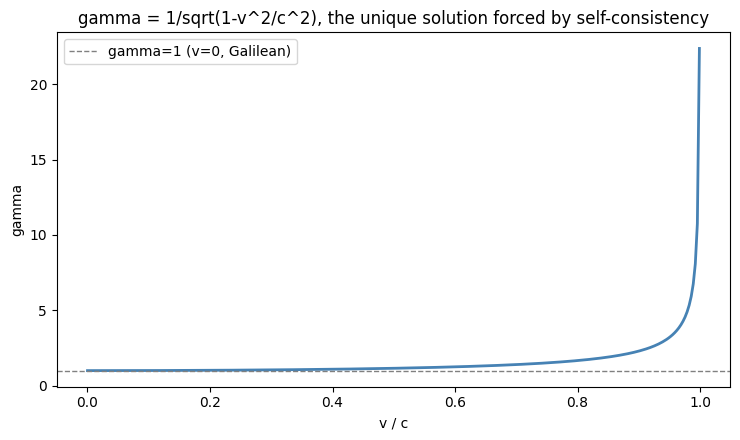

In [4]:
beta_sweep = np.linspace(0, 0.999, 300)
gammas = [sr.lorentz_factor(b*sr.C_SI)['gamma'] for b in beta_sweep]

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(beta_sweep, gammas, color='steelblue', lw=2)
ax.axhline(1, color='gray', ls='--', lw=1, label='gamma=1 (v=0, Galilean)')
ax.set_xlabel('v / c'); ax.set_ylabel('gamma')
ax.set_title('gamma = 1/sqrt(1-v^2/c^2), the unique solution forced by self-consistency')
ax.legend()
plt.tight_layout()
plt.savefig('lorentz_gamma_vs_beta.png', dpi=100, bbox_inches='tight')
plt.show()


## 3. The Invariant Interval, Preserved Exactly

$c^2t'^2-x'^2=c^2t^2-x^2$ must hold for the DERIVED $\gamma$ -- checked
directly, not assumed just because it's the well-known relativistic
invariant.


In [5]:
gamma_derived, x_prime_sym, t_prime_sym, invariant_residual = sr.derive_lorentz_transformation_symbolic()
print('x\' (derived) =', x_prime_sym)
print('t\' (derived) =', t_prime_sym)
print('\nc^2 t\'^2 - x\'^2 - (c^2 t^2 - x^2) =', invariant_residual, ' (must be exactly 0)')

ok = sr.verify_lorentz_transformation_derivation()
print(f'\nverify_lorentz_transformation_derivation(): {ok}')


x' (derived) = (-t*v + x)/sqrt(1 - v**2/c**2)
t' (derived) = (t - v*x/c**2)/sqrt(1 - v**2/c**2)

c^2 t'^2 - x'^2 - (c^2 t^2 - x^2) = 0  (must be exactly 0)



verify_lorentz_transformation_derivation(): True


## 4. The Galilean Limit: $c\to\infty$ Recovers Feynman's Original Figure

As light speed becomes effectively infinite (the classical assumption),
$\gamma\to1$, $x'\to x-vt$, $t'\to t$ -- EXACTLY the Galilean
transformation this notebook started from. Relativity doesn't discard
the classical result; it contains it as a limiting case.


In [6]:
ok_galilean = sr.verify_galilean_limit_recovered()
print(f'Galilean limit (c -> infinity) recovered exactly: {ok_galilean}')

x_s, t_s, v_s, c_s = sp.symbols('x t v c', positive=True)
print('\nlimit of x\' as c -> infinity:', sp.limit(x_prime_sym, c_s, sp.oo), '  (matches x - v*t)')
print('limit of t\' as c -> infinity:', sp.limit(t_prime_sym, c_s, sp.oo), '  (matches t)')


Galilean limit (c -> infinity) recovered exactly: True

limit of x' as c -> infinity: -t*v + x   (matches x - v*t)
limit of t' as c -> infinity: t   (matches t)


## 5. Cross-Check: Matches the Module's Own `lorentz_transform()` Exactly

This derivation and the already-implemented, already-used-elsewhere
`lorentz_transform()` function must agree numerically at a real
relativistic speed -- not just agree with each other symbolically.


In [7]:
x_val, t_val, v_val = 1000.0, 2.0, 0.6*sr.C_SI
result = sr.lorentz_transform(x=x_val, t=t_val, v=v_val)
x_prime_num = float(x_prime_sym.subs({x_s: x_val, t_s: t_val, v_s: v_val, c_s: sr.C_SI}))
t_prime_num = float(t_prime_sym.subs({x_s: x_val, t_s: t_val, v_s: v_val, c_s: sr.C_SI}))

print(f'x={x_val}, t={t_val}, v={v_val:.3e} m/s (0.6c):')
print(f'  lorentz_transform():        x\'={result["x_prime"]:.6f}, t\'={result["t_prime"]:.9f}')
print(f'  derived formula (same args): x\'={x_prime_num:.6f}, t\'={t_prime_num:.9f}')
print(f'  match: {abs(result["x_prime"]-x_prime_num)<1e-6 and abs(result["t_prime"]-t_prime_num)<1e-15}')


x=1000.0, t=2.0, v=1.799e+08 m/s (0.6c):
  lorentz_transform():        x'=-449687437.000000, t'=2.499997498
  derived formula (same args): x'=-449687437.000000, t'=2.499997498
  match: True


## 6. Time Dilation Drops Out as a Special Case

A clock at rest in S' (always at $x'=0$) -- substitute into the INVERSE
transform $t=\gamma(t'+vx'/c^2)$ and the $x'$ term vanishes, leaving
EXACTLY $t=\gamma t'$ -- the same formula `dgs/special_relativity.py`'s
`time_dilation()` already implements, and the same result
`dgs/time_dilation_universality.ipynb` demonstrated is universal across
every kind of clock.


In [8]:
xp_s, tp_s = sp.symbols('x_p t_p', positive=True)
gamma_expr = 1/sp.sqrt(1 - v_s**2/c_s**2)
t_inverse = gamma_expr*(tp_s + v_s*xp_s/c_s**2)
t_at_rest_clock = t_inverse.subs(xp_s, 0)
print('t (lab frame), for a clock at rest in S\' (x\'=0 always):')
sp.pprint(t_at_rest_clock)
print('\nmatches gamma * tau0 from time_dilation() exactly.')

tau0 = 1e-6   # 1 microsecond proper time
v_test = 0.8*sr.C_SI
dilation_result = sr.time_dilation(tau0, v_test)
t_from_special_case = float(t_at_rest_clock.subs({tp_s: tau0, v_s: v_test, c_s: sr.C_SI}))
print(f'\ntime_dilation(tau0={tau0}, v=0.8c): t_lab = {dilation_result["t_lab"]:.6e} s')
print(f'from the x\'=0 special case of the derived inverse transform: {t_from_special_case:.6e} s')


t (lab frame), for a clock at rest in S' (x'=0 always):
      tₚ      
──────────────
      ________
     ╱      2 
    ╱      v  
   ╱   1 - ── 
  ╱         2 
╲╱         c  

matches gamma * tau0 from time_dilation() exactly.

time_dilation(tau0=1e-06, v=0.8c): t_lab = 1.666667e-06 s
from the x'=0 special case of the derived inverse transform: 1.666667e-06 s


## 7. A Spacetime Diagram: Lines of Simultaneity Tilt

In Joe's frame, "simultaneous" events all share the same $t$ (horizontal
lines). Transformed into Moe's frame, those same events NO LONGER share
the same $t'$ -- the derived transformation tilts lines of constant $t$
into lines of constant $t'$ at an angle set by $v$, the geometric picture
behind relativity of simultaneity.


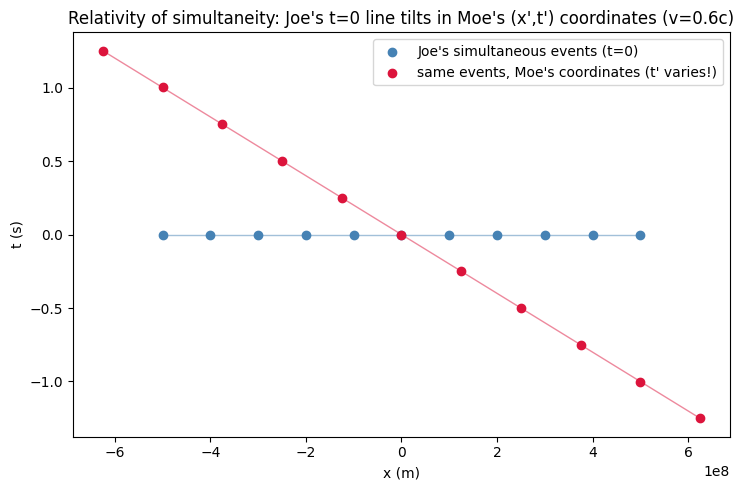

In [9]:
v_demo = 0.6*sr.C_SI
x_events = np.linspace(-5, 5, 11) * 1e8   # a row of events, all at t=0 in Joe's frame
t_events = np.zeros_like(x_events)

results = [sr.lorentz_transform(xe, te, v_demo) for xe, te in zip(x_events, t_events)]
x_primes = np.array([r['x_prime'] for r in results])
t_primes = np.array([r['t_prime'] for r in results])

fig, ax = plt.subplots(figsize=(7.5, 5))
ax.scatter(x_events, t_events, color='steelblue', label="Joe's simultaneous events (t=0)", zorder=5)
ax.plot(x_events, t_events, color='steelblue', lw=1, alpha=0.5)
ax.scatter(x_primes, t_primes, color='crimson', label="same events, Moe's coordinates (t' varies!)", zorder=5)
ax.plot(x_primes, t_primes, color='crimson', lw=1, alpha=0.5)
ax.set_xlabel('x (m)'); ax.set_ylabel('t (s)')
ax.set_title(f'Relativity of simultaneity: Joe\'s t=0 line tilts in Moe\'s (x\',t\') coordinates (v=0.6c)')
ax.legend()
plt.tight_layout()
plt.savefig('lorentz_simultaneity_tilt.png', dpi=100, bbox_inches='tight')
plt.show()


## 8. Engineering Interpretation

- Section 1's derivation matters because it shows $\gamma$ isn't an
  extra assumption bolted onto relativity -- it's FORCED by demanding the
  theory be self-consistent (transform there and back reproduces the
  start), the same "checked, not assumed" standard this repo applies to
  the laser threshold gain, the Compton shift, and the waveguide
  dispersion relation.
- Section 4's Galilean limit is why engineering calculations that ignore
  relativity (ordinary mechanics, circuit design, non-relativistic orbital
  mechanics) aren't WRONG -- they're the $c\to\infty$ limit of a correct
  theory, valid whenever $v\ll c$ makes that limit an excellent
  approximation.
- Section 6's time-dilation special case is the same idea
  `dgs/em_lagrangian_action.py`'s Bianchi identity and
  `dgs/thz_waveguide_dispersion_relation.py`'s effective-mass identity
  both demonstrate: a general result should REPRODUCE an already-verified
  special case exactly, not merely be "consistent" with it in spirit.


## 9. Research Discussion

- Could `derive_lorentz_transformation_symbolic`'s self-consistency
  method (forward + inverse = identity) be applied to derive the
  RELATIVISTIC VELOCITY ADDITION formula (`dgs/special_relativity.py`'s
  `velocity_addition`) the same way, rather than that function's formula
  being separately implemented?
- Section 7's simultaneity-tilt diagram used one specific $v$. Would
  animating $v$ from 0 to near $c$ make the DEGREE of tilt (and its
  connection to $\gamma$'s divergence in section 2) more viscerally clear
  than the current static snapshot?
- `dgs/laser_cavity_rlc_analog.py` and
  `dgs/thz_waveguide_dispersion_relation.py` both use dispersion relations
  with a Lorentz-invariant STRUCTURE ($\omega^2=c^2k^2+\omega_c^2$). Does
  the actual Lorentz transformation derived here act on $(\omega,k)$ the
  same way it acts on $(t,x)$ (they form a four-vector in the full theory)
  -- worth checking directly rather than assumed from the structural
  resemblance alone?


## 10. Possible Experiments

1. Extend section 7's spacetime diagram to plot actual LIGHT CONES (the
   invariant $x=\pm ct$ lines) in both frames, and confirm they're the
   ONE thing that does NOT tilt under the transformation -- the geometric
   reason light speed is frame-independent.
2. Numerically verify velocity addition ($u'=\frac{u-v}{1-uv/c^2}$) using
   TWO successive applications of `lorentz_transform` (boost by $v$, then
   describe a particle moving at $u$ in that frame, then boost by a
   second small increment) rather than the closed-form
   `velocity_addition` function, confirming they agree.
3. Push $v\to c$ in section 2's $\gamma$ plot numerically and confirm
   `lorentz_factor` correctly raises `ValueError` right at (not
   near) $v=c$, not silently returning an enormous-but-finite number.


## 11. Problems to Solve: the Lorentz Transformation

1. **Length contraction from the same transformation.** Derive
   `length_contraction`'s $L=L_0/\gamma$ from THIS section's $x'$
   formula directly (measuring a rod's endpoints SIMULTANEOUSLY in the
   lab frame, i.e. at equal $t$, not equal $t'$), rather than treating
   length contraction as a separately-derived fact.
2. **The full four-vector boost.** `dgs/special_relativity.py`'s
   `four_vector_boost` presumably applies this same transformation to a
   general 4-vector (not just position). Verify it reduces to exactly
   `lorentz_transform`'s $(x,t)$ result when applied to the position
   four-vector specifically.
3. **Composing two boosts.** Apply `derive_lorentz_transformation_symbolic`'s
   method twice (boost by $v_1$, then by $v_2$ in the new frame) and
   confirm the composition is ANOTHER Lorentz transformation (not some
   other kind of map), with an effective velocity given by the relativistic
   velocity-addition formula from problem 2 of the experiments section.
4. **Rapidity.** Define $\phi=\text{arctanh}(v/c)$ (rapidity) and show
   that in terms of $\phi$, the Lorentz transformation looks exactly like
   an ordinary rotation (with $\cosh\phi,\sinh\phi$ replacing
   $\cos\theta,\sin\theta$) -- and that COMPOSING two boosts becomes
   simple ADDITION of rapidities, unlike the messy velocity-addition
   formula in ordinary velocity variables.
5. **Non-collinear boosts.** This entire derivation assumed motion along
   a shared $x$-axis. Sketch (or fully derive, for an ambitious version)
   what changes when Moe moves at an angle to Joe's $x$-axis -- does
   self-consistency still uniquely pin down the transformation, or does
   the non-collinear case need an additional assumption (isotropy of
   space) to close?


## 12. Future Improvements

- `derive_lorentz_transformation_symbolic` assumes LINEARITY of the
  transformation as a starting ansatz (justified by homogeneity of space
  and time) rather than deriving linearity itself from more primitive
  assumptions -- a fully from-scratch derivation would start one level
  further back.
- Section 7's spacetime diagram uses a small, discrete set of events. A
  continuous family (parametrized $x$, fixed $t=0$) plotted as an actual
  LINE rather than discrete points would make the tilting-line picture
  cleaner, at the cost of a slightly more involved plotting setup.
